# Quantum gates are unitary matrices

### Subject: Mathematical foundations

All the linear algebra you study — matrices, eigenvalues, tensor products — is
exactly the language of qubits. In this notebook we verify the fundamental
properties **by hand** with NumPy.

**Roadmap**
1. Unitarity: $U U^\dagger = I$
2. Eigenvalues of the Pauli gates (modulus 1)
3. Tensor product: from 1 qubit to 2 qubits
4. Superposition via the Hadamard gate


## 0. Setup


In [1]:
import sys
from pathlib import Path

# Make quantum/_common importable whether the kernel cwd is the repo root
# or the subject folder.
_here = Path.cwd().resolve()
for candidate in (_here, _here.parent, _here.parent.parent):
    if (candidate / "_common").is_dir():
        sys.path.insert(0, str(candidate))
        break

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

from _common import PAULI_X, PAULI_Y, PAULI_Z, HADAMARD, ket0, ket1, is_unitary

print("Imports OK. ket0 shape:", ket0.shape)


Imports OK. ket0 shape: (2, 1)


## 1. Unitarity

A quantum gate must preserve probabilities, which means it must be **unitary**:
$U^\dagger U = I$. The Pauli matrices $X, Y, Z$ and the Hadamard $H$ all satisfy this.


In [2]:
gates = {"X": PAULI_X, "Y": PAULI_Y, "Z": PAULI_Z, "H": HADAMARD}
for name, gate in gates.items():
    print(f"{name}: unitary? {is_unitary(gate)}")
    print(f"   U U^dagger =\n{np.round(gate @ gate.conj().T, 6).real}\n")


X: unitary? True
   U U^dagger =
[[1. 0.]
 [0. 1.]]

Y: unitary? True
   U U^dagger =
[[1. 0.]
 [0. 1.]]

Z: unitary? True
   U U^dagger =
[[1. 0.]
 [0. 1.]]

H: unitary? True
   U U^dagger =
[[1. 0.]
 [0. 1.]]



## 2. Eigenvalues of the Pauli gates

Unitary matrices have eigenvalues on the unit circle: $|\lambda| = 1$.
For the Paulis the eigenvalues are simply $\pm 1$.


In [3]:
for name, gate in {"X": PAULI_X, "Y": PAULI_Y, "Z": PAULI_Z}.items():
    eigvals = np.linalg.eigvals(gate)
    print(f"{name}: eigenvalues = {np.round(eigvals, 3)}  "
          f"|lambda| = {np.round(np.abs(eigvals), 3)}")


X: eigenvalues = [ 1.+0.j -1.+0.j]  |lambda| = [1. 1.]
Y: eigenvalues = [ 1.+0.j -1.+0.j]  |lambda| = [1. 1.]
Z: eigenvalues = [ 1.+0.j -1.+0.j]  |lambda| = [1. 1.]


## 3. Tensor product: 1 qubit → 2 qubits

Two independent qubits live in the tensor-product space
$\mathbb{C}^2 \otimes \mathbb{C}^2 = \mathbb{C}^4$.
The state $|0\rangle\otimes|1\rangle = |01\rangle$ is a 4-component vector.
A gate on the first qubit alone is $H\otimes I$ (a $4\times 4$ unitary).


In [4]:
state_01 = np.kron(ket0, ket1)
print("|0> (x) |1> = |01> ->", state_01.real.astype(int).flatten())

H_otimes_I = np.kron(HADAMARD, np.eye(2))
print(f"dim(H (x) I) = {H_otimes_I.shape}  unitary? {is_unitary(H_otimes_I)}")


|0> (x) |1> = |01> -> [0 1 0 0]
dim(H (x) I) = (4, 4)  unitary? True


## 4. Superposition with Hadamard

$$ H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}} $$

Amplitudes are equal; so are the Born probabilities $P(0)=P(1)=\tfrac12$.


Amplitudes     = [0.707+0.j 0.707+0.j]
Probabilities  = [0.5 0.5]


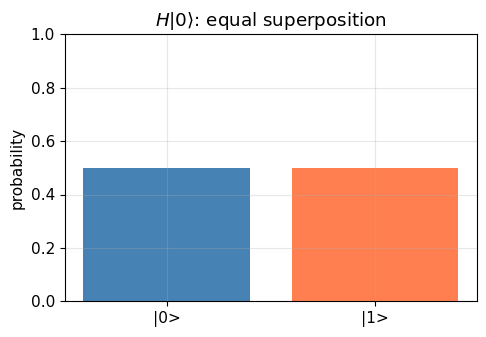

In [5]:
psi = HADAMARD @ ket0
probs = np.abs(psi.flatten()) ** 2
print("Amplitudes     =", np.round(psi.flatten(), 3))
print("Probabilities  =", np.round(probs, 3))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(["|0>", "|1>"], probs, color=["steelblue", "coral"])
ax.set_ylim(0, 1)
ax.set_ylabel("probability")
ax.set_title(r"$H|0\rangle$: equal superposition")
plt.tight_layout()
plt.show()


### Next steps
- Prove that $X, Y, Z$ anticommute: $\{X,Y\}=0$, etc.
- Pauli eigenvectors as measurement bases ($X$-basis, $Y$-basis).
- For the full bra–ket → eigenfunction story, see
  `../03_quantum_mechanics/02_bra_ket_operators_eigenfunctions.ipynb`.
